# Dammed reaches: climate zone vs CSI

**Question:** Among RiverATLAS reaches that **host a Global Dam Watch dam** (`gdw` on `hyriv_id`), how does **mean FFR connectivity status index (CSI)** differ by **global climate stratum** (`clz_cl_cmj`)?

**Strata:** `clz_cl_cmj` is HydroATLAS’s discrete climate class (1–18). Figures use **zone names** on axes; the summary table keeps the **letter code** and **numeric class** so you can filter in SQL (e.g. `WHERE clz_cl_cmj = 11`).

**Data:** `riveratlas` ⋈ `gdw` ⋈ `ffr`. Run `clean_data.py` then `ingest.py` from the repo root (or `ROOT = ROOT.parent` when the notebook lives under `notebooks/`).


In [9]:
from pathlib import Path

import duckdb
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import BoundaryNorm, ListedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

ROOT = Path.cwd().resolve()
if not (ROOT / "database" / "superbadd.duckdb").is_file():
    ROOT = ROOT.parent

DB = ROOT / "database" / "superbadd.duckdb"
con = duckdb.connect(str(DB), read_only=True)
con.execute("LOAD spatial;")

# Internal lookup: genz_id matches HydroATLAS clz_cl_cmj (1–18).
GENZ_CATALOG = pd.DataFrame(
    [
        (1, "A", "Arctic cold"),
        (2, "B", "Arctic"),
        (3, "C", "Subarctic cold"),
        (4, "D", "Subarctic"),
        (5, "E", "Very cold winter and dry"),
        (6, "F", "Cold and dry"),
        (7, "G", "Very cold winter and mesic"),
        (8, "H", "Cold and mesic"),
        (9, "I", "Very cold winter and wet"),
        (10, "J", "Cold and wet"),
        (11, "K", "Warm temperate and mesic"),
        (12, "L", "Warm temperate and dry"),
        (13, "M", "Warm temperate and hot"),
        (14, "N", "Hot and dry"),
        (15, "O", "Hot and mesic"),
        (16, "P", "Very hot and dry"),
        (17, "Q", "Very hot and mesic"),
        (18, "R", "Moist and hot"),
    ],
    columns=["genz_id", "genz_code", "genz_name"],
)

# Publication palette: one hex per class ID (1–18), cold→hot / dry→wet logic.
ZONE_HEX = [
    "#E6F1FF",
    "#B7C0CB",
    "#A1EDDE",
    "#4D93DD",
    "#D1E1FF",
    "#98D4FF",
    "#81C1E7",
    "#27A8F7",
    "#010C30",
    "#3B1E59",
    "#72B043",
    "#FFD9AA",
    "#F8CC1B",
    "#FFBE88",
    "#FF886B",
    "#F53B3B",
    "#E12729",
    "#800000",
]
zone_cmap = ListedColormap(ZONE_HEX)
zone_norm = BoundaryNorm(np.arange(0.5, 19.5, 1), zone_cmap.N)


def zone_hex_for_id(zone_id: int) -> str:
    i = int(zone_id) - 1
    if 0 <= i < len(ZONE_HEX):
        return ZONE_HEX[i]
    return "#888888"


def zone_name(zone_id: int) -> str:
    row = GENZ_CATALOG.loc[GENZ_CATALOG["genz_id"] == int(zone_id)]
    if row.empty:
        return str(int(zone_id))
    return str(row.iloc[0]["genz_name"])


## Summary table

**Climate zone** is the readable stratum name. **Letter** and **class code** are what you need to recover rows in SQL (`clz_cl_cmj` equals the class code).


In [ ]:
summary_sql = """
WITH dammed_reach AS (
    SELECT DISTINCT r.hyriv_id, r.clz_cl_cmj, f.csi AS csi
    FROM riveratlas AS r
    INNER JOIN gdw AS g ON r.hyriv_id = g.hyriv_id
    INNER JOIN ffr AS f ON f.hyriv_id = r.hyriv_id
    WHERE r.clz_cl_cmj IS NOT NULL
      AND g.hyriv_id IS NOT NULL
      AND f.csi IS NOT NULL
)
SELECT
    clz_cl_cmj AS climate_zone_code,
    COUNT(*) AS n_reaches,
    ROUND(AVG(csi), 4) AS mean_csi,
    ROUND(STDDEV(csi), 4) AS sd_csi,
    ROUND(MEDIAN(csi), 4) AS median_csi,
    MIN(csi) AS min_csi,
    MAX(csi) AS max_csi
FROM dammed_reach
GROUP BY clz_cl_cmj
ORDER BY mean_csi ASC;
"""
summary = con.execute(summary_sql).df()
summary = summary.merge(
    GENZ_CATALOG,
    how="left",
    left_on="climate_zone_code",
    right_on="genz_id",
)
summary_display = summary.rename(
    columns={
        "genz_name": "Climate zone",
        "genz_code": "Letter code",
        "climate_zone_code": "Class code (clz_cl_cmj)",
        "n_reaches": "Dam reach count",
        "mean_csi": "Mean CSI",
        "sd_csi": "SD CSI",
        "median_csi": "Median CSI",
        "min_csi": "Min CSI",
        "max_csi": "Max CSI",
    }
)[
    [
        "Climate zone",
        "Letter code",
        "Class code (clz_cl_cmj)",
        "Dam reach count",
        "Mean CSI",
        "SD CSI",
        "Median CSI",
        "Min CSI",
        "Max CSI",
    ]
]
summary_display


,Climate zone,Letter code,Class code (clz_cl_cmj),Dam reach count,Mean CSI,SD CSI,Median CSI,Min CSI,Max CSI
0,Subarctic cold,C,3,14,32.4343,9.4026,26.7205,25.26076,54.58113
1,Very cold winter and dry,E,5,272,43.1816,23.0331,35.4547,25.06853,100.00000
2,Hot and mesic,O,15,115,53.3668,33.1309,40.6853,14.11313,100.00000
3,Warm temperate and dry,L,12,1800,54.5248,30.1927,47.4206,9.88962,100.00000
4,Cold and dry,F,6,264,56.8059,31.3457,43.4194,24.50108,100.00000
5,Very cold winter and wet,I,9,1327,60.3043,30.7554,52.3015,9.43539,100.00000
6,Very cold winter and mesic,G,7,1810,60.6039,27.3052,54.0266,19.91313,100.00000
7,Cold and mesic,H,8,2375,61.9519,29.2879,53.9727,10.01445,100.00000
8,Warm temperate and hot,M,13,2528,65.6322,25.6078,56.2000,15.52211,100.00000
9,Warm temperate and mesic,K,11,6565,65.8543,28.1280,56.4077,13.58915,100.00000


## Mean CSI by climate zone

Horizontal bars for strata with at least **100** dammed reaches (names only on the vertical axis).


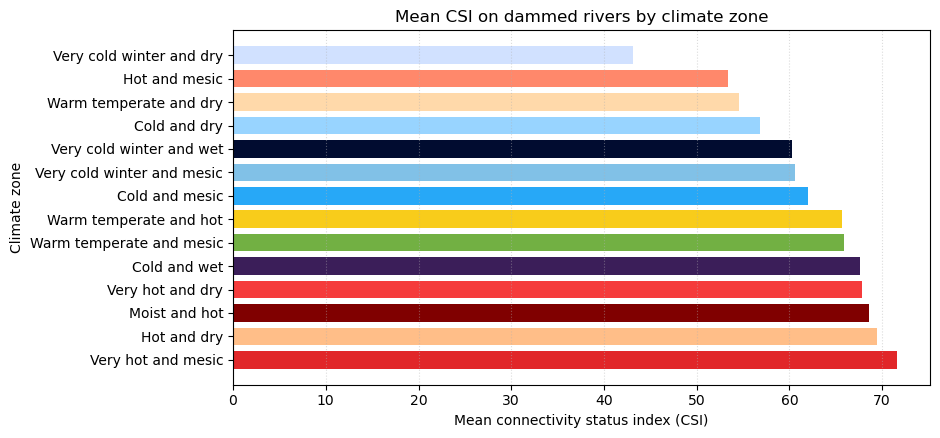

In [3]:
min_n = 100
plot_df = summary[summary["n_reaches"] >= min_n].sort_values("mean_csi", ascending=True)
plot_df = plot_df.assign(axis_name=plot_df["climate_zone_code"].map(zone_name))
bar_colors = [zone_hex_for_id(int(z)) for z in plot_df["climate_zone_code"]]

fig, ax = plt.subplots(figsize=(9.5, max(4.2, 0.32 * len(plot_df))))
ax.barh(plot_df["axis_name"], plot_df["mean_csi"], color=bar_colors, height=0.75)
ax.set_xlabel("Mean connectivity status index (CSI)")
ax.set_ylabel("Climate zone")
ax.set_title(f"Mean CSI on dammed rivers by climate zone")
ax.invert_yaxis()
ax.grid(axis="x", linestyle=":", alpha=0.45)
plt.tight_layout()


## Stratum size versus mean CSI

Each point is one climate stratum. **Dashed line:** ordinary least-squares fit to the displayed points. **Colour** encodes HydroATLAS class code (same palette as the bar chart above).


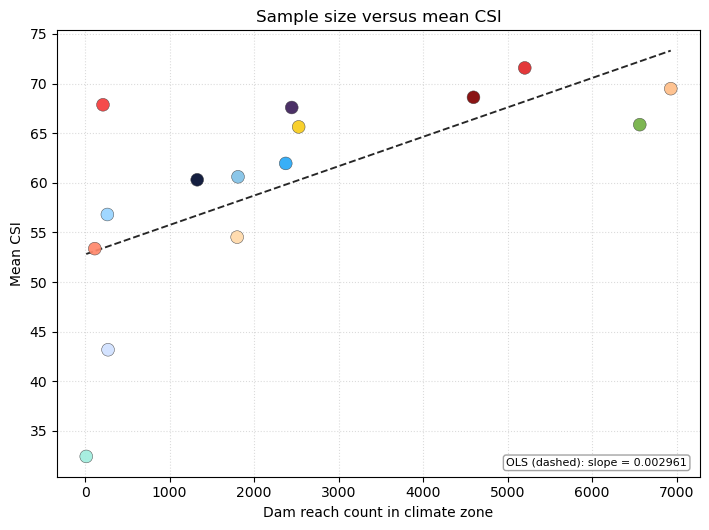

In [4]:
fig, ax = plt.subplots(figsize=(7.2, 5.4))
x = summary["n_reaches"].astype(float)
y = summary["mean_csi"].astype(float)
ax.scatter(
    x,
    y,
    c=summary["climate_zone_code"],
    cmap=zone_cmap,
    norm=zone_norm,
    s=85,
    alpha=0.92,
    edgecolors="0.25",
    linewidths=0.35,
    zorder=3,
)
coef = None
if len(summary) >= 2 and np.nanstd(x) > 0:
    coef = np.polyfit(x, y, 1)
    xx = np.linspace(float(x.min()), float(x.max()), 200)
    ax.plot(xx, np.poly1d(coef)(xx), color="0.15", linestyle="--", linewidth=1.35, zorder=2)
ax.set_xlabel("Dam reach count in climate zone")
ax.set_ylabel("Mean CSI")
ax.set_title("Sample size versus mean CSI")
ax.grid(True, linestyle=":", alpha=0.45)

if coef is not None:
    ax.annotate(
        f"OLS (dashed): slope = {coef[0]:.4g}",
        xy=(0.98, 0.02),
        xycoords="axes fraction",
        ha="right",
        va="bottom",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="0.6", alpha=0.9),
    )

plt.tight_layout()


## Uncertainty in the mean CSI

Approximate **95% confidence intervals** for the mean (normal approximation: ±1.96 × SD/√n). Same strata as the bar chart (n ≥ threshold).


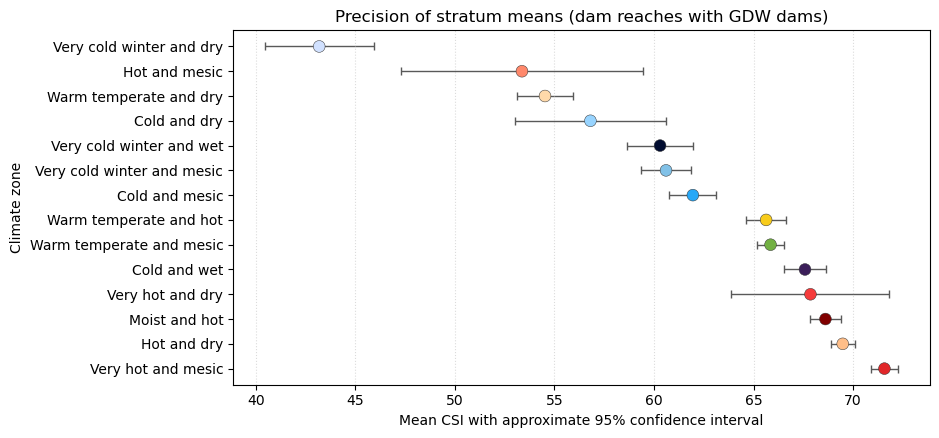

In [5]:
min_n = 100
plot_s = summary[summary["n_reaches"] >= min_n].sort_values("mean_csi", ascending=True)
se = plot_s["sd_csi"] / np.sqrt(plot_s["n_reaches"].astype(float))
lo = plot_s["mean_csi"] - 1.96 * se
hi = plot_s["mean_csi"] + 1.96 * se
y = np.arange(len(plot_s))
names = plot_s["climate_zone_code"].map(zone_name)
colors = [zone_hex_for_id(int(z)) for z in plot_s["climate_zone_code"]]

fig, ax = plt.subplots(figsize=(9.5, max(4.2, 0.32 * len(plot_s))))
ax.errorbar(
    plot_s["mean_csi"],
    y,
    xerr=[plot_s["mean_csi"] - lo, hi - plot_s["mean_csi"]],
    fmt="none",
    ecolor="0.35",
    elinewidth=1.0,
    capsize=3,
    zorder=1,
)
ax.scatter(plot_s["mean_csi"], y, c=colors, s=72, edgecolors="0.2", linewidths=0.35, zorder=3)
ax.set_yticks(y)
ax.set_yticklabels(names)
ax.set_xlabel("Mean CSI with approximate 95% confidence interval")
ax.set_ylabel("Climate zone")
ax.set_title("Precision of stratum means (dam reaches with GDW dams)")
ax.grid(axis="x", linestyle=":", alpha=0.45)
ax.invert_yaxis()
plt.tight_layout()


## Geographic distribution (reach centroids)

One map: each point is one dammed reach **centroid** (lines are hard to render). **Every** reach that passes the SQL filters is shown (no subsample). **Colour** = HydroATLAS class code (1–18) with the stratum palette in the setup cell; **marker size** scales with **CSI** (2nd–98th percentile stretch so outliers do not dominate). The horizontal bar is the class-code colour scale.


centroid rows: 15337


/tmp/ipykernel_512344/1084556715.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


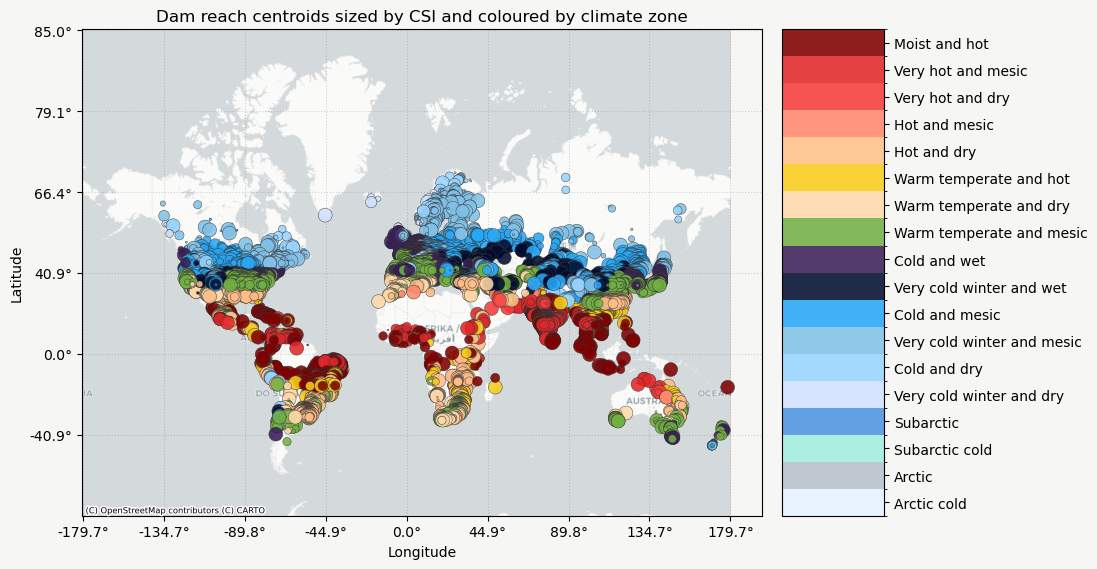

In [20]:
import contextily as ctx
from matplotlib import ticker as mticker
from pyproj import Transformer

MAP_MIN_LEN = 0.06  # drop only very short segments
# Plot every dammed reach (no hash subsample). Large datasets: slower query/render;
# reduce point count only if needed (e.g. raise MAP_MIN_LEN or simplify geometry in SQL).
centroid_sql = f"""
WITH dammed AS (
    SELECT DISTINCT r.hyriv_id, r.clz_cl_cmj, f.csi
    FROM riveratlas AS r
    INNER JOIN gdw AS g ON r.hyriv_id = g.hyriv_id
    INNER JOIN ffr AS f ON f.hyriv_id = r.hyriv_id
    WHERE r.clz_cl_cmj IS NOT NULL AND f.csi IS NOT NULL
)
SELECT
    d.clz_cl_cmj,
    d.csi,
    ST_X(ST_Centroid(r.geometry)) AS lon,
    ST_Y(ST_Centroid(r.geometry)) AS lat
FROM dammed AS d
INNER JOIN riveratlas AS r ON r.hyriv_id = d.hyriv_id
WHERE r.shape_length > {MAP_MIN_LEN}
  AND r.geometry IS NOT NULL;
"""
cdf = con.execute(centroid_sql).df()
print(f"centroid rows: {len(cdf)}")
cdf = cdf.dropna(subset=["lon", "lat", "csi"])
cdf = cdf[(cdf["lon"].between(-180, 180)) & (cdf["lat"].between(-90, 90))]

fig, ax = plt.subplots(figsize=(11, 5.8))
fig.patch.set_facecolor("#f6f6f4")
if len(cdf) == 0:
    ax.text(0.5, 0.5, "No centroids to plot", ha="center", va="center", transform=ax.transAxes)
else:
    gdf = gpd.GeoDataFrame(
        cdf,
        geometry=gpd.points_from_xy(cdf["lon"], cdf["lat"]),
        crs="EPSG:4326",
    )
    gdf_m = gdf.to_crs(3857)
    minx, miny, maxx, maxy = gdf_m.total_bounds
    span = max(maxx - minx, maxy - miny, 1e3)
    buf = 0.06 * span
    ax.set_xlim(minx - buf, maxx + buf)
    ax.set_ylim(miny - buf, maxy + buf)

    ctx.add_basemap(
        ax,
        crs=gdf_m.crs,
        source=ctx.providers.CartoDB.Positron,
        zorder=0,
        attribution_size=6,
        reset_extent=False,
    )

    csi = cdf["csi"].astype(float)
    lo, hi = csi.quantile(0.02), csi.quantile(0.98)
    t = (csi.clip(lo, hi) - lo) / max(hi - lo, 1e-9)
    sizes = 100 * t

    sc = ax.scatter(
        gdf_m.geometry.x,
        gdf_m.geometry.y,
        c=cdf["clz_cl_cmj"],
        cmap=zone_cmap,
        norm=zone_norm,
        s=sizes,
        alpha=0.88,
        edgecolors="0.2",
        linewidths=0.35,
        zorder=2,
    )
    ax.set_aspect("equal", adjustable="box")

    inv = Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True)

    def lon_fmt(x, pos):
        ymid = sum(ax.get_ylim()) / 2
        lon, _ = inv.transform(x, ymid)
        return f"{lon:.1f}°"

    def lat_fmt(y, pos):
        xmid = sum(ax.get_xlim()) / 2
        _, lat = inv.transform(xmid, y)
        return f"{lat:.1f}°"

    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lon_fmt))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lat_fmt))

    ax.set_title("Dam reach centroids sized by CSI and coloured by climate zone")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_facecolor("none")
    ax.grid(True, color="0.35", alpha=0.25, linestyle=":", zorder=1)

    cbar_ax = inset_axes(
        ax,
        width="15%",
        height="100%",
        loc="center left",
        bbox_to_anchor=(1.02, 0, 1, 1),
        bbox_transform=ax.transAxes,
    )
    cbar = plt.colorbar(sc, cax=cbar_ax, ticks=np.arange(1, 19))
    cbar.ax.set_yticklabels([zone_name(i) for i in range(1, 19)])

plt.tight_layout()


## Interpretation checklist

- **Lowest mean CSI:** sort the summary table by **Mean CSI**.
- **SQL filter:** use **Class code (clz_cl_cmj)** (and join keys `hyriv_id` as elsewhere in the project).
- **Caveats:** strata are coarse; dams are not randomized across climate; CSI is a segment metric (FFR), not a dam-only effect.

---

*Close the database connection when finished.*


In [21]:
con.close()
